# PageIndex vs Vector RAG — Full Demo & Evaluation

This notebook runs **two RAG approaches** on the same PDF and compares them using **GEval** (5 metrics).

| | Approach | Retrieval | Chunking |
|---|---|---|---|
| 🗂 | **PageIndex RAG** | LLM navigates a hierarchical structure tree | Semantic sections via LLM |
| 🔍 | **Vector RAG** | FAISS cosine search over sentence embeddings | Section-based (PageIndex boundaries) |

Text extraction for both approaches uses **Docling** (markdown tables, structured text).

## 0. Setup

In [1]:
import sys, subprocess
from pathlib import Path

SRC_DIR = Path('../src').resolve()
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

r = subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-q', '-r', '../requirements.txt'],
    capture_output=True, text=True
)
print('Dependencies OK' if r.returncode == 0 else r.stderr[-300:])

Dependencies OK


In [2]:
import json, warnings
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from IPython.display import Markdown, display, JSON
warnings.filterwarnings('ignore')

from index_pdf  import find_pdf, run_indexing, DATA_DIR, RESULTS_DIR, print_structure_tree
from qa_system  import load_structure, find_structure_json, answer_question, flatten_nodes, DEFAULT_QUESTION as QUESTION
from vector_rag import vector_rag_answer
from evaluation import compare_answers

print(f'Question:\n{QUESTION}')

Question:
How did the company's total revenue and operating margin change in Q1 FY25 compared to the previous year, and which business segments contributed most to this change?


---
## Part 1 — PageIndex: Hierarchical Structure

In [3]:
pdf_path  = find_pdf(DATA_DIR)
structure = run_indexing(pdf_path, RESULTS_DIR)
json_path = find_structure_json(RESULTS_DIR)

display(Markdown(f"""
**Document:** {structure.get('doc_name', '')}

**Description:** {structure.get('doc_description', '')}
"""))

[index_pdf] Cached result found: /Users/soumendusekharbhattacharjee/Documents/DATA-SCIENCE/Page_Index/results/q1-fy25-earnings_structure.json



**Document:** q1-fy25-earnings.pdf

**Description:** A comprehensive financial and operational report detailing The Walt Disney Company's first-quarter fiscal 2025 performance, including revenue growth, segment-specific results, guidance for the fiscal year, and key metrics for streaming, parks, and sports, along with non-GAAP financial measures and forward-looking statements.


In [4]:
print('=== PageIndex Structure Tree ===')
print_structure_tree(structure.get('structure', []))

=== PageIndex Structure Tree ===
0000  THE WALT DISNEY COMPANY REPORTS FIRST QUARTER EARNINGS FOR FISCAL 2025  [p1–1]
  └─ 0001  Financial Results for the Quarter  [p1–1]
    └─ 0002  Key Points  [p1–1]
0003  Guidance and Outlook  [p2–2]
  └─ 0004  Star India deconsolidated in Q1  [p2–2]
  └─ 0005  Q2 Fiscal 2025  [p2–2]
  └─ 0006  Fiscal Year 2025  [p2–2]
  └─ 0007  Message From Our CEO  [p2–2]
0008  SUMMARIZED FINANCIAL RESULTS  [p3–3]
  └─ 0009  SUMMARIZED SEGMENT FINANCIAL RESULTS  [p3–3]
0010  DISCUSSION OF FIRST QUARTER SEGMENT RESULTS  [p4–4]
  └─ 0011  Star India  [p4–4]
  └─ 0012  Entertainment  [p4–4]
    └─ 0013  Linear Networks  [p5–5]
    └─ 0014  Direct-to-Consumer  [p5–7]
    └─ 0015  Content Sales/Licensing and Other  [p7–7]
  └─ 0016  Sports  [p7–7]
    └─ 0017  Domestic ESPN  [p8–8]
    └─ 0018  International ESPN  [p8–8]
    └─ 0019  Star India  [p8–8]
  └─ 0020  Experiences  [p9–9]
    └─ 0021  Domestic Parks and Experiences  [p9–9]
    └─ 0022  International Parks 

In [5]:
flat_nodes = flatten_nodes(structure.get('structure', []))
df_nodes = pd.DataFrame([
    {
        'node_id': n['node_id'],
        'depth'  : n['depth'],
        'title'  : '  ' * n['depth'] + n['title'],
        'pages'  : f"{n['start_index']}\u2013{n['end_index']}",
        'summary': (n['summary'] or '')[:110] + '\u2026',
    }
    for n in flat_nodes if n['node_id']
])
pd.set_option('display.max_colwidth', 120)
df_nodes.style.hide(axis='index')

node_id,depth,title,pages,summary
0000,0,THE WALT DISNEY COMPANY REPORTS FIRST QUARTER EARNINGS FOR FISCAL 2025,1–1,The partial document provides a summary of The Walt Disney Company's financial performance for the first fisca…
0001,1,Financial Results for the Quarter,1–1,The partial document provides a summary of The Walt Disney Company's financial performance for the first fisca…
0002,2,Key Points,1–1,The partial document provides a summary of The Walt Disney Company's financial performance for the first quart…
0003,0,Guidance and Outlook,2–2,"The partial document outlines Disney's financial guidance and outlook for fiscal 2025, highlighting key perfor…"
0004,1,Star India deconsolidated in Q1,2–2,"The partial document outlines Disney's financial guidance and outlook for fiscal 2025, highlighting key perfor…"
0005,1,Q2 Fiscal 2025,2–2,"The partial document outlines Disney's financial guidance and outlook for fiscal 2025, highlighting key perfor…"
0006,1,Fiscal Year 2025,2–2,"The partial document outlines Disney's financial guidance and outlook for fiscal 2025, highlighting key perfor…"
0007,1,Message From Our CEO,2–2,"The partial document outlines Disney's financial guidance and outlook for fiscal 2025, highlighting key perfor…"
0008,0,SUMMARIZED FINANCIAL RESULTS,3–3,The partial document provides a summarized overview of financial results for the first quarter of fiscal years…
0009,1,SUMMARIZED SEGMENT FINANCIAL RESULTS,3–3,The partial document provides a summarized overview of financial results for the first quarter of fiscal years…


---
## Part 2 — Answer Generation

Both RAG approaches answer the **same question** from the same PDF.

In [6]:
display(Markdown(f'> **Question:** *{QUESTION}*'))

> **Question:** *How did the company's total revenue and operating margin change in Q1 FY25 compared to the previous year, and which business segments contributed most to this change?*

### 2a. PageIndex RAG
LLM reads the structure tree → selects relevant nodes → Docling extracts those pages → Azure OpenAI answers.

In [7]:
pi_result = answer_question(QUESTION, pdf_path, json_path)

nodes_md = '\n'.join(
    f"- `[{n['node_id']}]` **{n['title']}** \u2014 pages {n['pages']}"
    for n in pi_result['relevant_nodes']
)
pages_md = ', '.join(f"{s}\u2013{e}" for s, e in pi_result['pages_retrieved'])
display(Markdown(f"""
**Sections selected by LLM navigation:**
{nodes_md}

**Pages retrieved (Docling):** {pages_md}
"""))

[qa_system] Loaded 43 nodes from index.
[qa_system] Relevant nodes selected: ['0008', '0009', '0010', '0013', '0014', '0020']
[qa_system] Fetching pages: [(3, 3), (4, 4), (5, 5), (5, 7), (9, 9)]
[qa_system] Parsing PDF with Docling: q1-fy25-earnings.pdf (one-time, cached)…
[qa_system] Docling parsing complete.
[qa_system] Generating answer...



**Sections selected by LLM navigation:**
- `[0008]` **SUMMARIZED FINANCIAL RESULTS** — pages 3–3
- `[0009]` **SUMMARIZED SEGMENT FINANCIAL RESULTS** — pages 3–3
- `[0010]` **DISCUSSION OF FIRST QUARTER SEGMENT RESULTS** — pages 4–4
- `[0013]` **Linear Networks** — pages 5–5
- `[0014]` **Direct-to-Consumer** — pages 5–7
- `[0020]` **Experiences** — pages 9–9

**Pages retrieved (Docling):** 3–3, 4–4, 5–5, 5–7, 9–9


In [8]:
display(Markdown(f"""
---
### \U0001f5c2 PageIndex RAG \u2014 Answer

{pi_result['answer']}
"""))


---
### 🗂 PageIndex RAG — Answer

### Revenue and Operating Margin Increased in Q1 FY25, Driven by Entertainment and Sports Segments

- **Total Revenue Growth**
  - Increased by 5% from $23,549 million in Q1 FY24 to $24,690 million in Q1 FY25 [p.3].

- **Operating Margin Growth**
  - Total segment operating income rose by 31%, from $3,876 million in Q1 FY24 to $5,060 million in Q1 FY25 [p.3].

- **Key Contributing Business Segments**
  - **Entertainment Segment**
    - Revenue increased by 9%, from $9,981 million to $10,872 million [p.3].
    - Operating income surged by 95%, from $874 million to $1,703 million [p.3].
    - Growth was driven by improved results in Content Sales/Licensing and Direct-to-Consumer, partially offset by a decline in Linear Networks [p.4].
  - **Sports Segment**
    - Revenue remained flat at $4,850 million [p.3].
    - Operating income improved significantly, from a loss of $103 million to a profit of $247 million [p.3].
    - The improvement was primarily due to better results at Star India and ESPN International [p.7].

📌 **Key Takeaway**: The company's total revenue grew by 5%, and operating margin increased by 31% in Q1 FY25, with the Entertainment segment (95% operating income growth) and Sports segment (turnaround to profitability) being the primary drivers.


### 2b. Section-Based Vector RAG
Section chunks (from PageIndex boundaries) → sentence-transformers embeddings → FAISS top-5 → Azure OpenAI answers.

In [9]:
vr_result = vector_rag_answer(QUESTION, pdf_path, structure, top_k=5)

chunks_md = '\n'.join(
    f"- `[{c['node_id']}]` **{c['title']}** \u2014 pages {c['pages']}"
    for c in vr_result['retrieved_chunks']
)
display(Markdown(f"""
**Top-5 chunks retrieved by FAISS (sentence-transformers):**
{chunks_md}
"""))

[vector_rag] Created 22 section chunks from 22 unique page ranges.
[vector_rag] Loading embedding model: all-MiniLM-L6-v2…
[vector_rag] Embedding model loaded.
[vector_rag] Embedding 22 chunks…
[vector_rag] FAISS index built — 22 vectors, dim=384.
[vector_rag] Retrieved 5 chunks for the query.
[vector_rag] Generating answer…



**Top-5 chunks retrieved by FAISS (sentence-transformers):**
- `[0039]` **Total segment operating income** — pages 19–20
- `[0000]` **THE WALT DISNEY COMPANY REPORTS FIRST QUARTER EARNINGS FOR FISCAL 2025** — pages 1–1
- `[0008]` **SUMMARIZED FINANCIAL RESULTS** — pages 3–3
- `[0003]` **Guidance and Outlook** — pages 2–2
- `[0020]` **Experiences** — pages 9–9


In [10]:
display(Markdown(f"""
---
### \U0001f50d Vector RAG \u2014 Answer

{vr_result['answer']}
"""))


---
### 🔍 Vector RAG — Answer

### Revenue and Operating Margin Changes in Q1 FY25

• **Total Revenue**:  
  ◦ Increased by 5% to $24.7 billion in Q1 FY25, compared to $23.5 billion in Q1 FY24 [p.1, p.3].

• **Total Segment Operating Income**:  
  ◦ Increased by 31% to $5.1 billion in Q1 FY25, compared to $3.9 billion in Q1 FY24 [p.1, p.3].

• **Key Business Segment Contributions**:  
  ◦ **Entertainment**: Operating income increased by 95% to $1.7 billion, driven by strong box office performance and improved profitability in Direct-to-Consumer streaming [p.1, p.3].  
  ◦ **Sports**: Operating income rose significantly to $247 million from a $103 million loss in Q1 FY24, reflecting a turnaround in performance [p.3].  
  ◦ **Experiences**: Operating income remained flat at $3.1 billion, with international parks showing a 28% increase, offset by a 5% decline in domestic parks due to hurricanes and pre-opening expenses [p.1, p.3, p.9].

📌 **Key Takeaway**: The company's 31% increase in total segment operating income was primarily driven by a 95% surge in Entertainment operating income and a significant recovery in the Sports segment.


---
## Part 3 — GEval Comparison (5 Metrics)

**Evaluation framework:** DeepEval GEval  
**Judge LLM:** Azure OpenAI gpt-4o  
**Reference:** Full PDF extracted via Docling (up to 40 000 chars) — no gold-standard answer needed

| Metric | What it measures |
|---|---|
| Answer Relevancy | Does the answer address the question? |
| Faithfulness | Every claim grounded in retrieved content? |
| Completeness | Key PDF facts covered? |
| Conciseness | Appropriately detailed, not verbose or sparse? |
| Coherence | Logically structured and easy to follow? |

In [11]:
comparison = compare_answers(QUESTION, pi_result, vr_result, pdf_path)

[evaluation] Extracting full PDF context for Completeness metric…
[evaluation] Full PDF context: 40,017 chars.

[evaluation] Evaluating 'PageIndex RAG' across 5 metrics…
  • Answer Relevancy… 

Output()

score=1.0
  • Faithfulness… 

Output()

score=1.0
  • Completeness… 

...

score=1.0
  • Conciseness… 

Output()

score=0.9
  • Coherence… 

Output()

score=0.9


### 3a. Score Summary

In [12]:
df_summary = pd.DataFrame(comparison['summary'])
df_summary.columns = ['Metric', 'PageIndex RAG', 'Vector RAG', 'Winner']

def color_winner(row):
    styles = [''] * len(row)
    if row['Winner'] == 'PageIndex RAG':
        styles[1] = 'background-color:#d4edda;font-weight:bold'
    elif row['Winner'] == 'Vector RAG':
        styles[2] = 'background-color:#d4edda;font-weight:bold'
    else:
        styles[1] = styles[2] = 'background-color:#fff3cd'
    return styles

display(df_summary.style
    .apply(color_winner, axis=1)
    .hide(axis='index')
    .format({'PageIndex RAG': '{:.3f}', 'Vector RAG': '{:.3f}'}))

Metric,PageIndex RAG,Vector RAG,Winner
Answer Relevancy,1.000,1.000,Tie
Faithfulness,1.000,1.000,Tie
Completeness,0.900,1.000,Vector RAG
Conciseness,1.000,0.900,PageIndex RAG
Coherence,0.900,0.900,Tie


### 3b. Score Chart

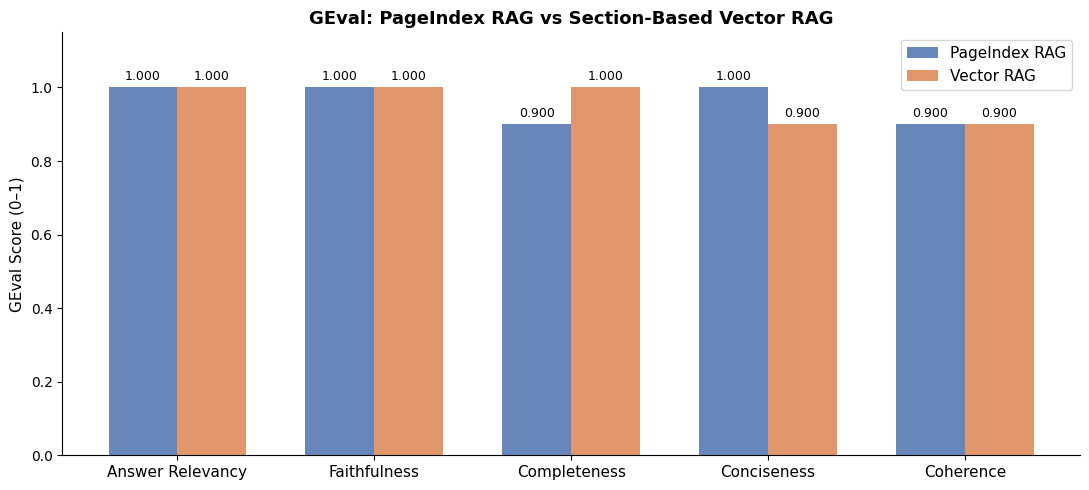

Chart saved → results/geval_comparison.png


In [13]:
metrics   = [r['metric']          for r in comparison['summary']]
pi_scores = [r['pageindex_score'] for r in comparison['summary']]
vr_scores = [r['vector_score']    for r in comparison['summary']]

x = range(len(metrics))
w = 0.35
fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar([i - w/2 for i in x], pi_scores, w, label='PageIndex RAG', color='#4C72B0', alpha=0.85)
b2 = ax.bar([i + w/2 for i in x], vr_scores,  w, label='Vector RAG',    color='#DD8452', alpha=0.85)
ax.bar_label(b1, fmt='%.3f', padding=3, fontsize=9)
ax.bar_label(b2, fmt='%.3f', padding=3, fontsize=9)
ax.set_xticks(list(x))
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel('GEval Score (0\u20131)', fontsize=11)
ax.set_title('GEval: PageIndex RAG vs Section-Based Vector RAG', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('../results/geval_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved \u2192 results/geval_comparison.png')

### 3c. Detailed Reasoning — PageIndex RAG

In [14]:
for r in comparison['pageindex']['scores']:
    display(Markdown(f"""
**{r['metric']}** \u2014 score: `{r['score']}`

> {r['reason']}

---"""))


**Answer Relevancy** — score: `1.0`

> The response directly addresses the question by providing a detailed comparison of total revenue and operating margin changes in Q1 FY25 versus the previous year. It also identifies the Entertainment and Sports segments as the primary contributors, with specific data points and explanations for their impact. The output is complete, focused, and does not introduce unrelated information, fully aligning with the evaluation steps.

---


**Faithfulness** — score: `1.0`

> The response aligns strongly with the evaluation steps. The input question is clear and directly addressed in the output. All factual claims, including revenue growth (5%), operating margin increase (31%), and segment-specific details (e.g., Entertainment's 95% operating income growth and Sports' turnaround to profitability), are explicitly traceable to the retrieval context (e.g., page 3 for financial summaries and page 4 for segment details). No hallucinations or unverifiable statements are present, and the output accurately attributes growth drivers to specific business segments with supporting data from the context.

---


**Completeness** — score: `0.9`

> The response effectively addresses the Input question by clearly summarizing the changes in total revenue (5% increase) and operating margin (31% increase) in Q1 FY25 compared to Q1 FY24, as outlined in the Context. It identifies the Entertainment and Sports segments as the primary contributors, providing detailed metrics such as Entertainment's 95% operating income growth and Sports' turnaround from a loss to profitability. However, it omits minor details like the specific impact of Star India on Sports segment results, which could enhance completeness.

---


**Conciseness** — score: `1.0`

> The Actual Output fully addresses the Input by providing detailed comparisons of total revenue and operating margin changes between Q1 FY25 and the previous year, including specific percentages and figures. It identifies the Entertainment and Sports segments as key contributors, with clear explanations of their revenue and operating income changes, supported by relevant details such as segment-specific drivers. The response is concise, avoids excessive repetition, and aligns perfectly with the Input's intent.

---


**Coherence** — score: `0.9`

> The response is logically structured, presenting revenue and operating margin growth first, followed by detailed contributions from key business segments. It flows naturally, with clear subsections for Entertainment and Sports segments, and consistently explains the drivers of growth without contradictions. However, the explanation for the Sports segment could have elaborated slightly more on the flat revenue alongside the turnaround in operating income for completeness.

---

### 3d. Detailed Reasoning — Vector RAG

In [15]:
for r in comparison['vector_rag']['scores']:
    display(Markdown(f"""
**{r['metric']}** \u2014 score: `{r['score']}`

> {r['reason']}

---"""))


**Answer Relevancy** — score: `1.0`

> The Actual Output directly addresses the question by providing detailed changes in total revenue and operating margin for Q1 FY25 compared to the previous year. It also thoroughly identifies the business segments contributing to these changes, including Entertainment, Sports, and Experiences, with specific metrics and explanations for each segment. The response remains focused on the question and avoids introducing unrelated information.

---


**Faithfulness** — score: `1.0`

> The response aligns strongly with the evaluation steps. The input question is clear and directly addressed in the output. All factual claims, including revenue and operating margin changes, as well as contributions from business segments, are explicitly traceable to the retrieval context. No hallucinations or unverifiable statements are present, and all data points, such as the 5% revenue increase, 31% operating income growth, and specific segment contributions, are supported by the provided context.

---


**Completeness** — score: `1.0`

> The response fully aligns with the evaluation steps. The input question is clearly understood, as the response directly addresses changes in total revenue and operating margin, as well as the contributions of key business segments. The output accurately incorporates all relevant key facts and figures from the context, including the 5% increase in total revenue, the 31% increase in total segment operating income, and detailed contributions from the Entertainment, Sports, and Experiences segments. No important metrics or comparisons are omitted, and the response provides a comprehensive and accurate summary of the requested information.

---


**Conciseness** — score: `0.9`

> The response thoroughly addresses the Input's requirements by detailing changes in total revenue and operating margin, as well as identifying key business segments contributing to these changes. It avoids excessive repetition and provides specific figures and percentages for clarity. However, the explanation for the Experiences segment could have been slightly more concise, as the flat operating income is less relevant to the overall change focus.

---


**Coherence** — score: `0.9`

> The response is logically structured, presenting revenue and operating margin changes in a clear sequence with well-defined sections for total revenue, segment operating income, and key business segment contributions. Transitions between points are smooth, and the use of bullet points enhances clarity and ease of understanding. The explanation avoids ambiguity and uses precise language, though minor improvements could be made in elaborating on the impact of specific factors like hurricanes and pre-opening expenses.

---

---
## Part 4 — Save All Results

In [16]:
out = {
    'question'    : QUESTION,
    'pageindex'   : {'answer': pi_result['answer'], 'nodes': pi_result['relevant_nodes']},
    'vector_rag'  : {'answer': vr_result['answer'], 'chunks': vr_result['retrieved_chunks']},
    'geval'       : comparison['summary'],
    'geval_detail': {
        'pageindex' : comparison['pageindex']['scores'],
        'vector_rag': comparison['vector_rag']['scores'],
    },
}
out_path = Path('../results/full_comparison.json')
out_path.write_text(json.dumps(out, indent=2, ensure_ascii=False))
print(f'\u2713 Full results saved \u2192 {out_path}')

tally = Counter(r['winner'] for r in comparison['summary'])
display(Markdown(f"""
### Final Tally
| Approach | Metrics Won |
|---|---|
| PageIndex RAG | {tally.get('PageIndex RAG', 0)} |
| Vector RAG    | {tally.get('Vector RAG', 0)} |
| Tie           | {tally.get('Tie', 0)} |
"""))

✓ Full results saved → ../results/full_comparison.json



### Final Tally
| Approach | Metrics Won |
|---|---|
| PageIndex RAG | 1 |
| Vector RAG    | 1 |
| Tie           | 3 |
